<a href="https://colab.research.google.com/github/Kevantech/python-coursework/blob/main/Self_study_try_it_activity_12_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 12.1: Analysing the effects of hyperparameters on surrogate models

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Predicted variances smaller than 0. Setting those variances to 0.")

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, RationalQuadratic, Matern


To run this notebook, you’ll need scikit-learn version 1.0 or above. Use the cell below to check your current version. If it’s lower than 1.0, install the correct version before continuing by running the following command in your terminal:

`conda install scikit-learn=1.0`

In [2]:
print(sklearn.__version__)

1.6.1


## Gaussian process

Create the data set

In [3]:
np.random.seed(234) #Do not change the random seed
x = np.random.uniform(0, 10, (10, 1))

def true_function(x):
    return -(1.4 - 3.0 * x) * np.sin(x)

y = true_function(x)


In [4]:
y = y.ravel()  #Convert to 1D


In [5]:
# Baseline Gaussian Process model
kernel = 1.0 * RationalQuadratic(length_scale=1.0)
gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=9,
    random_state=42
)
gpr.fit(x, y)


GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1),
                         n_restarts_optimizer=9, random_state=42)

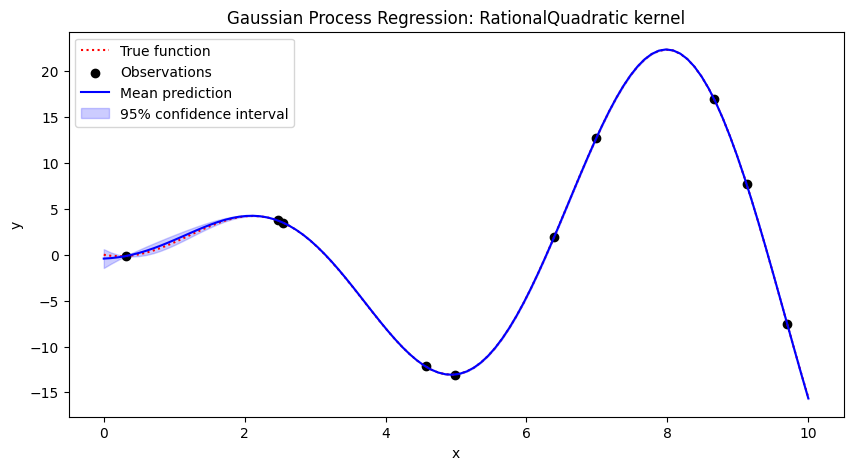

In [6]:
# Create test points
x_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, std = gpr.predict(x_test, return_std=True)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_test, true_function(x_test), 'r:', label='True function')
plt.scatter(x, y, c='k', label='Observations')
plt.plot(x_test, y_pred, 'b-', label='Mean prediction')
plt.fill_between(
    x_test.ravel(),
    y_pred - 1.96 * std,
    y_pred + 1.96 * std,
    alpha=0.2,
    color='blue',
    label='95% confidence interval'
)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Gaussian Process Regression: RationalQuadratic kernel')
plt.show()


## Answer the following questions

- Change the `length_scale` and observe the changes in the plot.

- Change the `kernel` to `Matern` and `RationalQuadratic` and observe the changes in the plot.

- Change the confidence intervals as follows and observe the plots:

  a. 68% confidence interval

  b. 90% confidence interval

  c. 99% confidence interval

### Gaussian process experiments

The cells below compare different length scales, kernels and confidence intervals.


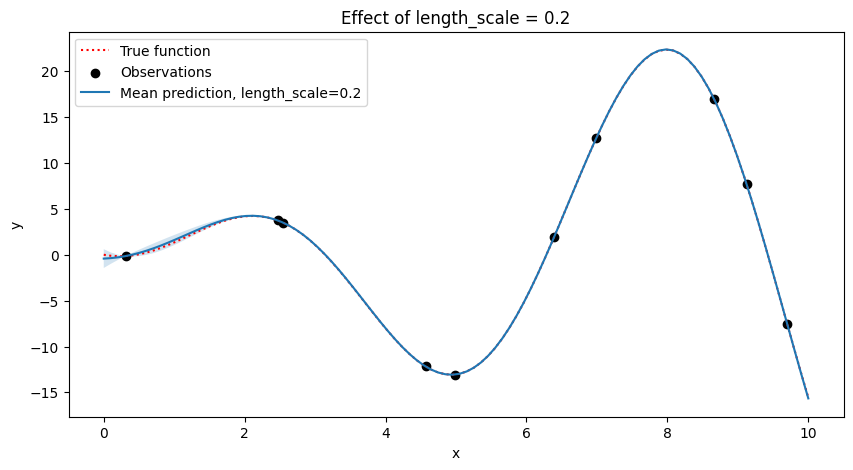

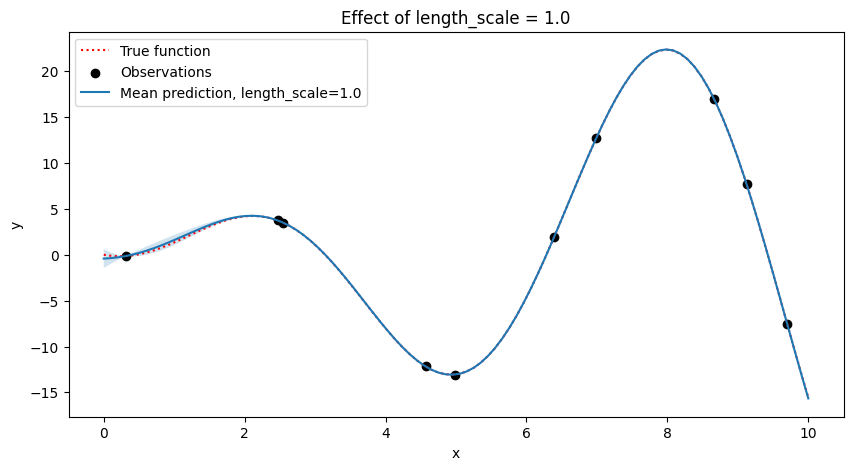

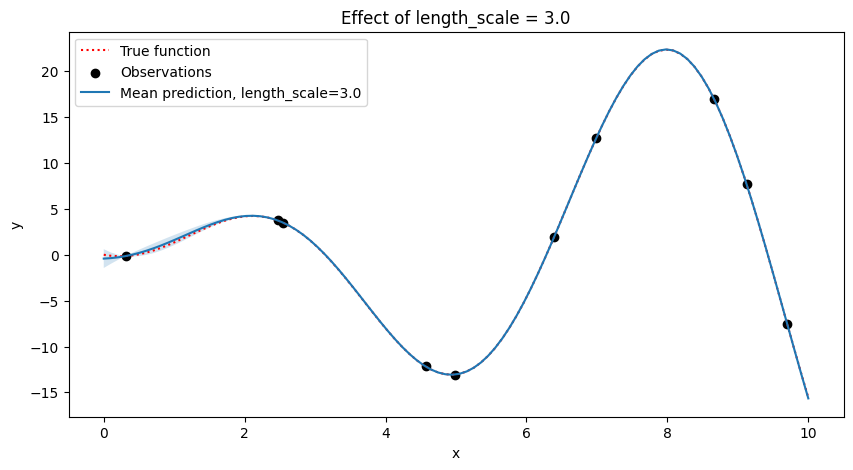

In [7]:
# Compare different length scales
length_scales = [0.2, 1.0, 3.0]

for ls in length_scales:
    kernel = 1.0 * RationalQuadratic(length_scale=ls)
    model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, random_state=42)
    model.fit(x, y)

    y_pred, std = model.predict(x_test, return_std=True)

    plt.figure(figsize=(10, 5))
    plt.plot(x_test, true_function(x_test), 'r:', label='True function')
    plt.scatter(x, y, c='k', label='Observations')
    plt.plot(x_test, y_pred, label=f'Mean prediction, length_scale={ls}')
    plt.fill_between(x_test.ravel(), y_pred - 1.96 * std, y_pred + 1.96 * std, alpha=0.2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Effect of length_scale = {ls}')
    plt.legend()
    plt.show()


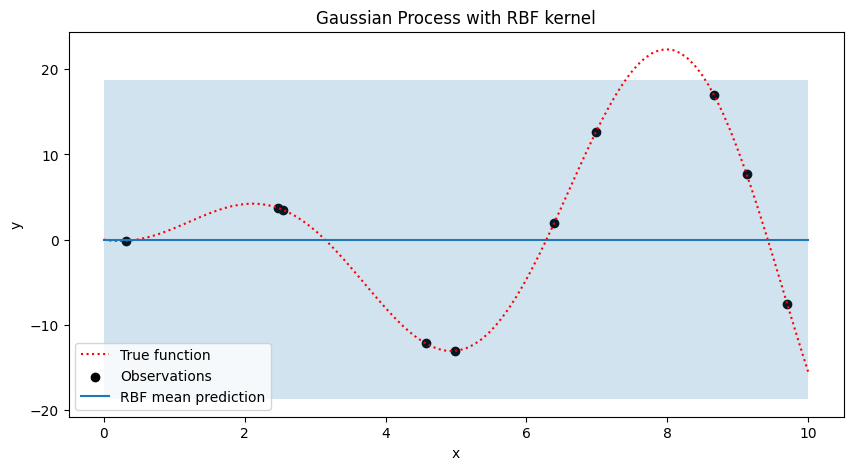

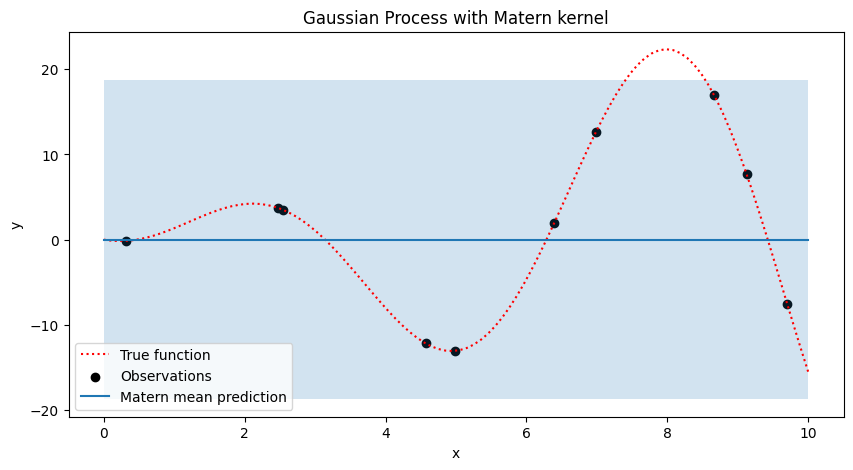

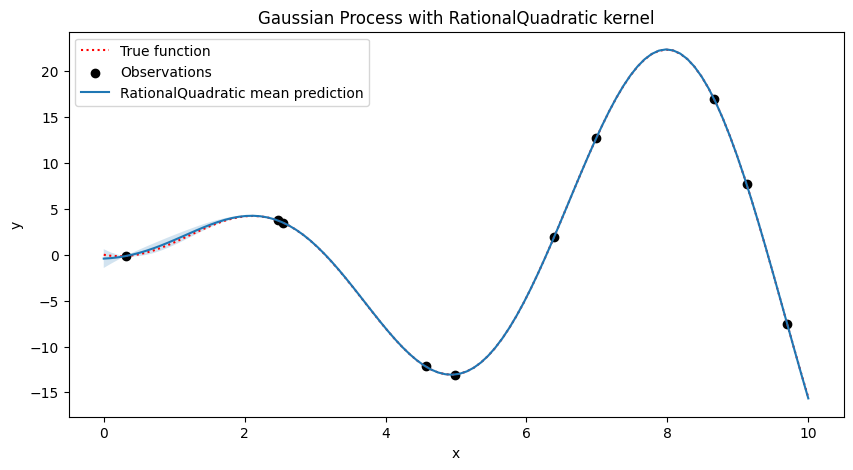

In [8]:
# Compare kernels
kernels = {
    "RBF": 1.0 * RBF(length_scale=1.0),
    "Matern": 1.0 * Matern(length_scale=1.0, nu=1.5),
    "RationalQuadratic": 1.0 * RationalQuadratic(length_scale=1.0)
}

for name, kernel in kernels.items():
    model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, random_state=42)
    model.fit(x, y)

    y_pred, std = model.predict(x_test, return_std=True)

    plt.figure(figsize=(10, 5))
    plt.plot(x_test, true_function(x_test), 'r:', label='True function')
    plt.scatter(x, y, c='k', label='Observations')
    plt.plot(x_test, y_pred, label=f'{name} mean prediction')
    plt.fill_between(x_test.ravel(), y_pred - 1.96 * std, y_pred + 1.96 * std, alpha=0.2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Gaussian Process with {name} kernel')
    plt.legend()
    plt.show()


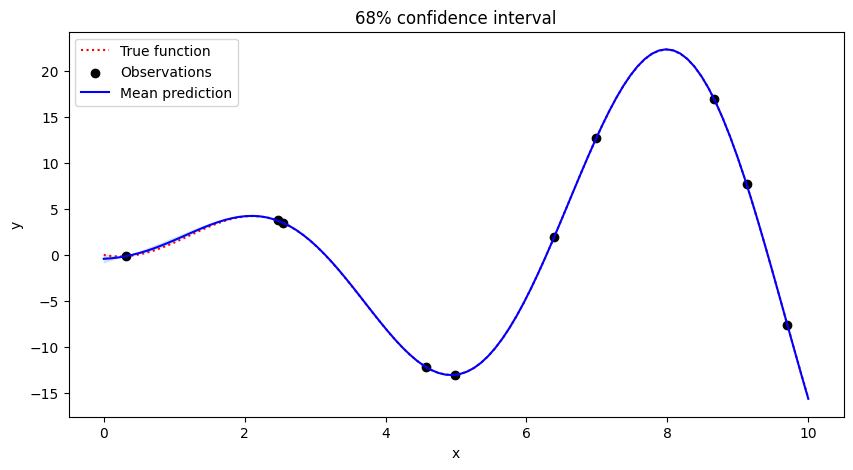

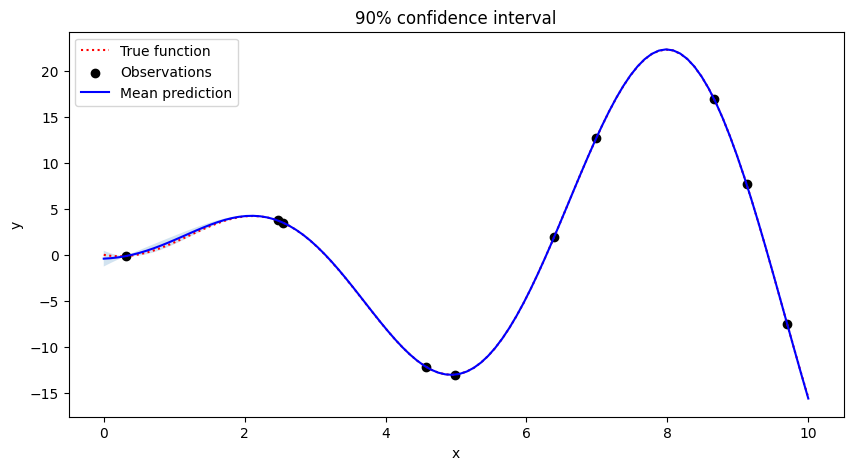

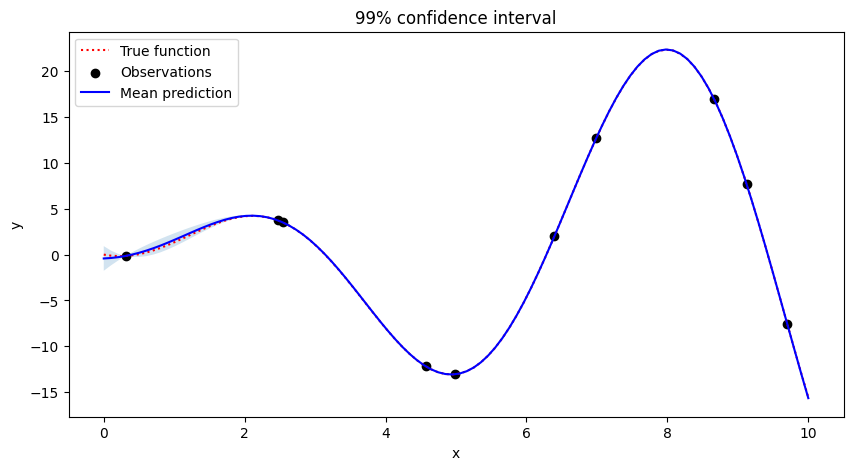

In [9]:
# Compare confidence intervals
# Multipliers: 68% ≈ 1.00, 90% ≈ 1.645, 99% ≈ 2.576
intervals = {
    "68%": 1.00,
    "90%": 1.645,
    "99%": 2.576
}

for label, z_value in intervals.items():
    y_pred, std = gpr.predict(x_test, return_std=True)

    plt.figure(figsize=(10, 5))
    plt.plot(x_test, true_function(x_test), 'r:', label='True function')
    plt.scatter(x, y, c='k', label='Observations')
    plt.plot(x_test, y_pred, 'b-', label='Mean prediction')
    plt.fill_between(x_test.ravel(), y_pred - z_value * std, y_pred + z_value * std, alpha=0.2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'{label} confidence interval')
    plt.legend()
    plt.show()


### Observations

- Smaller length scales make the model more flexible and wavy.
- Larger length scales make the model smoother.
- The Matern kernel can produce less smooth predictions than RBF.
- Wider confidence intervals, such as 99%, show more uncertainty than 68% or 90% intervals.


## Regression tree parameters

Explore how model parameters can affect the quality of the prediction.

## Follow these steps:

- Experiment with the hyperparameters of the regression trees below to build both the best and worst models you can.

- Use `help(DecisionTreeRegressor)` to explore the available hyperparameter options.

In [10]:
# Test grid for the decision tree models
x_test = np.linspace(0, 10, 100).reshape(-1, 1)


In [11]:
# Build a deliberately weak tree and a stronger tree for comparison

# Weak model: strongly restricted, so it underfits the data.
clf_worst = DecisionTreeRegressor(
    criterion="squared_error",
    splitter="best",
    max_depth=1,
    min_samples_leaf=5,
    random_state=42
)

# Strong model: flexible tree that can fit the small data set more closely.
clf_best = DecisionTreeRegressor(
    criterion="squared_error",
    splitter="best",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

clf_worst.fit(x, y)
clf_best.fit(x, y)

y_test_worst = clf_worst.predict(x_test)
y_test_best = clf_best.predict(x_test)
y_true = true_function(x_test)


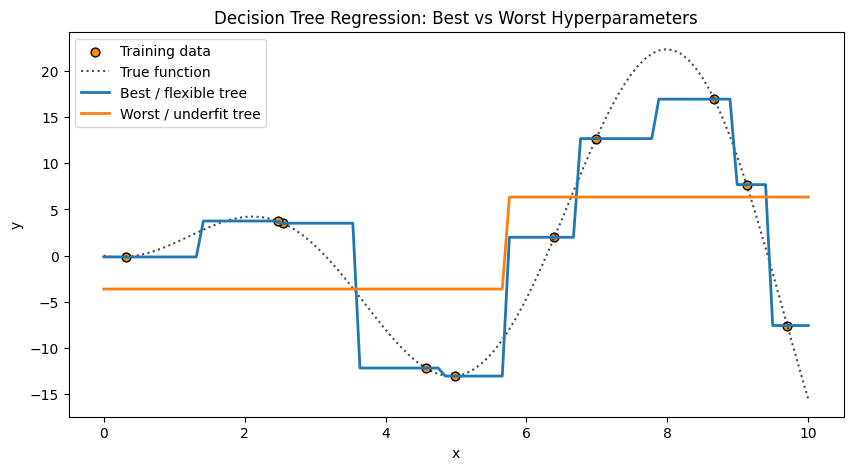

In [12]:
plt.figure(figsize=(10, 5))

# Plot shows: true function, stronger tree and weaker tree.
plt.scatter(x, y, s=40, edgecolor="black", c="darkorange", label="Training data")
plt.plot(x_test, y_true, color='k', linestyle=":", alpha=0.7, label='True function')
plt.plot(x_test, y_test_best, linewidth=2, label='Best / flexible tree')
plt.plot(x_test, y_test_worst, linewidth=2, label='Worst / underfit tree')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Decision Tree Regression: Best vs Worst Hyperparameters")
plt.legend()
plt.show()


### Decision tree observations

- The restricted tree underfits because it is only allowed to make a very small number of splits.
- The flexible tree follows the training points much more closely.
- For a small data set, a very flexible tree can look good on training data but may overfit.
